<a href="https://colab.research.google.com/github/karri-ten/LENET-MODEL-USING-SUBSET-OF-MNIST/blob/main/cifar10_two_class_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2><b>convolution model using a 2-class subset of the CIFAR-10 dataset.</b></h2>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


**Load Dataset**

In [3]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset

# Load CIFAR-10 but keep only class 3 (cat) and class 5 (dog)
# Use only 2 CIFAR-10 classes
class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

target_classes = ["cat", "dog"]
target_indices = [class_names.index(c) for c in target_classes]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

class FilteredCIFAR10(Dataset):
    def __init__(self, original_dataset, target_indices):
        self.original_dataset = original_dataset
        self.target_indices = target_indices
        self.filtered_data = []
        self.filtered_targets = []

        for i in range(len(original_dataset)):
            _, original_label = original_dataset[i]
            if original_label in target_indices:
                self.filtered_data.append(original_dataset[i][0]) # store image tensor
                self.filtered_targets.append(target_indices.index(original_label)) # remap label

    def __len__(self):
        return len(self.filtered_targets)

    def __getitem__(self, idx):
        return self.filtered_data[idx], self.filtered_targets[idx]


train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

# Create filtered datasets with remapped labels
train_small = FilteredCIFAR10(train_set, target_indices)
test_small  = FilteredCIFAR10(test_set, target_indices)

train_loader = DataLoader(train_small, batch_size=64, shuffle=True)
test_loader = DataLoader(test_small, batch_size=64, shuffle=False)

print(f"Train size: {len(train_small)}, Test size: {len(test_small)}")

Train size: 10000, Test size: 2000


**Define Model**

In [4]:
from torch.nn import Sequential

channel_base = 32
channel = [channel_base, channel_base, 2 * channel_base]

def create_analog_network(rpu_config=None, n_classes=2):
    ks = 5
    pad = 2
    stride = 1
    pool_ks = 3
    pool_pad = 1
    pool_stride = 2

    model = Sequential(
        # Conv 1
        nn.Conv2d(3, channel[0], ks, stride, pad),
        nn.BatchNorm2d(channel[0]),
        nn.ReLU(),
        nn.MaxPool2d(pool_ks, pool_stride, pool_pad),

        # Conv 2
        nn.Conv2d(channel[0], channel[1], ks, stride, pad),
        nn.BatchNorm2d(channel[1]),
        nn.ReLU(),
        nn.MaxPool2d(pool_ks, pool_stride, pool_pad),

        # Conv 3
        nn.Conv2d(channel[1], channel[2], ks, stride, pad),
        nn.BatchNorm2d(channel[2]),
        nn.ReLU(),
        nn.AvgPool2d(pool_ks, pool_stride, pool_pad),

        nn.Flatten(),
        nn.Linear(16 * channel[2], n_classes),
        nn.LogSoftmax(dim=1)
    )

    return model

model = create_analog_network()
device = "cuda" if torch.cuda.is_available() else "cpu"

# Added try-except block to handle AcceleratorError during model transfer to GPU
try:
    model = model.to(device)
    print(f"Model moved to {device} successfully.")
except Exception as e:
    if "device-side assert triggered" in str(e):
        print(f"AcceleratorError detected: {e}. Falling back to CPU.")
        device = "cpu"
        model = model.to(device)
    else:
        raise # Re-raise other unexpected errors

model

Model moved to cuda successfully.


Sequential(
  (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (8): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): AvgPool2d(kernel_size=3, stride=2, padding=1)
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=1024, out_features=2, bias=True)
  (14): LogSoftmax(dim=1)
)

**Loss amd Accuracy**

In [22]:
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 100
train_losses = []
test_losses = []
test_accuracies = []



**Training loop**

In [23]:
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        labels = labels.long() # Explicitly ensure labels are long type
        # Labels are already remapped to 0 and 1 by FilteredCIFAR10 dataset

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss)

    # Test evaluation
    model.eval()
    correct = 0
    total = 0
    test_loss = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            labels = labels.long() # Explicitly ensure labels are long type
            # Labels are already remapped to 0 and 1 by FilteredCIFAR10 dataset

            outputs = model(imgs)
            test_loss += criterion(outputs, labels).item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total
    test_losses.append(test_loss)
    test_accuracies.append(acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}]  Train Loss: {running_loss:.3f} | "
          f"Test Loss: {test_loss:.3f} | Accuracy: {acc:.3f}")

Epoch [1/100]  Train Loss: 5.777 | Test Loss: 32.559 | Accuracy: 0.803
Epoch [2/100]  Train Loss: 5.107 | Test Loss: 36.683 | Accuracy: 0.795
Epoch [3/100]  Train Loss: 1.941 | Test Loss: 29.517 | Accuracy: 0.817
Epoch [4/100]  Train Loss: 1.958 | Test Loss: 41.269 | Accuracy: 0.793
Epoch [5/100]  Train Loss: 7.079 | Test Loss: 31.058 | Accuracy: 0.789
Epoch [6/100]  Train Loss: 9.150 | Test Loss: 33.154 | Accuracy: 0.804
Epoch [7/100]  Train Loss: 1.695 | Test Loss: 29.203 | Accuracy: 0.823
Epoch [8/100]  Train Loss: 1.944 | Test Loss: 29.992 | Accuracy: 0.819
Epoch [9/100]  Train Loss: 0.371 | Test Loss: 29.562 | Accuracy: 0.829
Epoch [10/100]  Train Loss: 0.164 | Test Loss: 30.864 | Accuracy: 0.825
Epoch [11/100]  Train Loss: 0.128 | Test Loss: 31.134 | Accuracy: 0.826
Epoch [12/100]  Train Loss: 0.104 | Test Loss: 32.364 | Accuracy: 0.824
Epoch [13/100]  Train Loss: 0.106 | Test Loss: 32.343 | Accuracy: 0.824
Epoch [14/100]  Train Loss: 0.073 | Test Loss: 32.899 | Accuracy: 0.824
E

**Learning Plot curves**

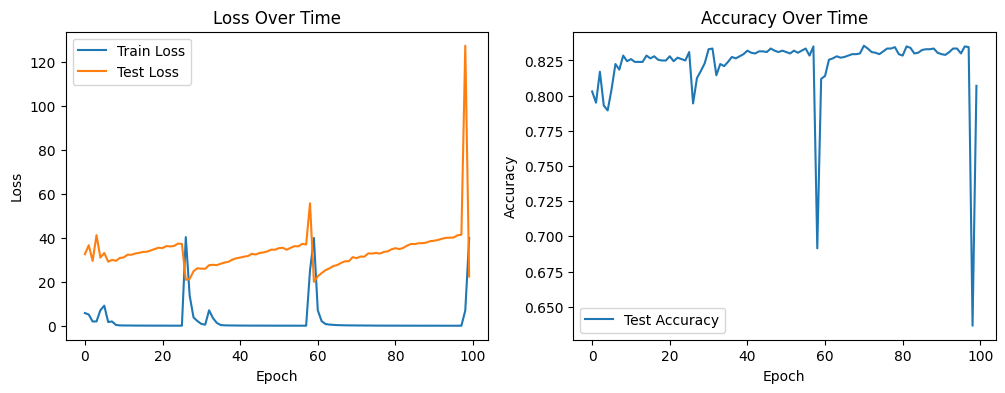

In [24]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(test_accuracies, label="Test Accuracy")
plt.title("Accuracy Over Time")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


**Confusion matrix**

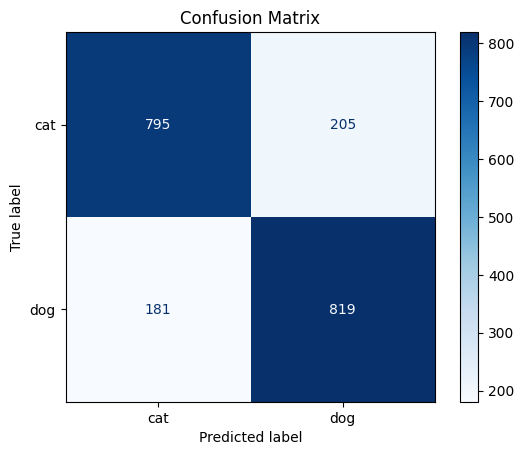

In [25]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=target_classes)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [26]:
torch.save(model.state_dict(), "cifar2_trained_model.pth")
print("Model saved.")


Model saved.


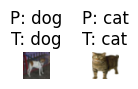

In [28]:
import random

model.eval()

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")

# pick 2 random samples
indices = random.sample(range(len(test_small)), 2)

plt.figure(figsize=(2, 1)) # Changed height

for i, idx in enumerate(indices):
    img, label = test_small[idx]
    img_input = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_input)
        _, pred = torch.max(output, 1)

    pred_label = target_classes[pred.item()]
    true_label = target_classes[label]

    plt.subplot(1, 2, i+1) # subplot for 2 images
    imshow(img.cpu())
    plt.title(f"P: {pred_label}\nT: {true_label}")
    plt.tight_layout()

plt.show()